In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


In [7]:
url = "https://www.basketball-reference.com/leagues/NBA_2023_per_game.html"

response = requests.get(url)
soup = BeautifulSoup(response.content, "html.parser")

table = soup.find("table", id="per_game_stats")

headers = [th.text for th in table.find("thead").find_all("th")][1:]  

rows = []
for tr in table.find("tbody").find_all("tr"):
    if tr.get("class") and "thead" in tr.get("class"):
        continue  
    cells = tr.find_all("td")
    if len(cells) > 0:
        rows.append([td.text for td in cells])


In [9]:
df = pd.DataFrame(rows, columns=headers)
print(df.head())


                    Player Age Team Pos   G  GS    MP    FG   FGA   FG%  ...  \
0              Joel Embiid  28  PHI   C  66  66  34.6  11.0  20.1  .548  ...   
1              Luka Dončić  23  DAL  PG  66  66  36.2  10.9  22.0  .496  ...   
2           Damian Lillard  32  POR  PG  58  58  36.3   9.6  20.7  .463  ...   
3  Shai Gilgeous-Alexander  24  OKC  PG  68  68  35.5  10.4  20.3  .510  ...   
4    Giannis Antetokounmpo  28  MIL  PF  63  63  32.1  11.2  20.3  .553  ...   

   ORB  DRB   TRB  AST  STL  BLK  TOV   PF   PTS                       Awards  
0  1.7  8.4  10.2  4.2  1.0  1.7  3.4  3.1  33.1  MVP-1,DPOY-9,CPOY-5,AS,NBA1  
1  0.8  7.8   8.6  8.0  1.4  0.5  3.6  2.5  32.4         MVP-8,CPOY-8,AS,NBA1  
2  0.8  4.0   4.8  7.3  0.9  0.3  3.3  1.9  32.2              CPOY-10,AS,NBA3  
3  0.9  4.0   4.8  5.5  1.6  1.0  2.8  2.8  31.4         MVP-5,CPOY-7,AS,NBA1  
4  2.2  9.6  11.8  5.7  0.8  0.8  3.9  3.1  31.1         MVP-3,DPOY-6,AS,NBA1  

[5 rows x 30 columns]


In [11]:
df.to_csv("nba_stats.csv", index=False)

In [13]:
df=pd.read_csv("nba_stats.csv")
df.head()

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,Joel Embiid,28.0,PHI,C,66.0,66.0,34.6,11.0,20.1,0.548,...,1.7,8.4,10.2,4.2,1.0,1.7,3.4,3.1,33.1,"MVP-1,DPOY-9,CPOY-5,AS,NBA1"
1,Luka Dončić,23.0,DAL,PG,66.0,66.0,36.2,10.9,22.0,0.496,...,0.8,7.8,8.6,8.0,1.4,0.5,3.6,2.5,32.4,"MVP-8,CPOY-8,AS,NBA1"
2,Damian Lillard,32.0,POR,PG,58.0,58.0,36.3,9.6,20.7,0.463,...,0.8,4.0,4.8,7.3,0.9,0.3,3.3,1.9,32.2,"CPOY-10,AS,NBA3"
3,Shai Gilgeous-Alexander,24.0,OKC,PG,68.0,68.0,35.5,10.4,20.3,0.510,...,0.9,4.0,4.8,5.5,1.6,1.0,2.8,2.8,31.4,"MVP-5,CPOY-7,AS,NBA1"
4,Giannis Antetokounmpo,28.0,MIL,PF,63.0,63.0,32.1,11.2,20.3,0.553,...,2.2,9.6,11.8,5.7,0.8,0.8,3.9,3.1,31.1,"MVP-3,DPOY-6,AS,NBA1"


In [15]:
print(f"num of rows:{df.shape[0]}")
print(f"num of cols:{df.shape[1]}")

num of rows:680
num of cols:30


In [19]:
df.columns

Index(['Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%',
       'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Awards'],
      dtype='object')

In [21]:
important_cols = [
    'Player', 'Age', 'Team', 'Pos', 'G', 'MP', 'PTS',
    'FG%', '3P%', '2P%', 'FT%', 'TRB', 'AST', 'STL', 'BLK'
]

df = df[important_cols]

In [63]:
#player:اسم اللاعب
#Age:عمر اللاعب
#Teeam: الفريق بتاعه
#Pos: مركزه ف الملعب
#G: عدد المباريات اللى شارك فيها
#MP: عدد الدقايق اللى لعبها ف الموسم
#PTS: اجمالى عدد النقاط اللى سجلها
#FG%: نسبه نجاحه ف تسجيل الاهداف
#3P%: نسبه النجاح فى التصويب من بعيد
#2P%: نسبه النجاح ف التصويب من قريب
#FT%: نسبه النجاح فى الرميات الحره = ضربات الجزاء
#TRB: مجموع الكرات الهجوميه والدفاعيه
#AST: عدد التمريرات الحاسمه
#STL: عدد الكرات اللى خطفها من الخصم
#BLK: عدد الكرات اللى صدها

In [23]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
675    False
676    False
677    False
678    False
679    False
Length: 680, dtype: bool

In [25]:
df = df.drop_duplicates()

In [27]:
df.isnull().sum()

Player     0
Age        1
Team       1
Pos        1
G          1
MP         1
PTS        1
FG%        3
3P%       24
2P%        7
FT%       37
TRB        1
AST        1
STL        1
BLK        1
dtype: int64

In [29]:
df = df.dropna()

In [31]:
df.isnull().sum()

Player    0
Age       0
Team      0
Pos       0
G         0
MP        0
PTS       0
FG%       0
3P%       0
2P%       0
FT%       0
TRB       0
AST       0
STL       0
BLK       0
dtype: int64

In [35]:
df.shape

(624, 15)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624 entries, 0 to 669
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  624 non-null    object 
 1   Age     624 non-null    float64
 2   Team    624 non-null    object 
 3   Pos     624 non-null    object 
 4   G       624 non-null    float64
 5   MP      624 non-null    float64
 6   PTS     624 non-null    float64
 7   FG%     624 non-null    float64
 8   3P%     624 non-null    float64
 9   2P%     624 non-null    float64
 10  FT%     624 non-null    float64
 11  TRB     624 non-null    float64
 12  AST     624 non-null    float64
 13  STL     624 non-null    float64
 14  BLK     624 non-null    float64
dtypes: float64(12), object(3)
memory usage: 78.0+ KB


In [39]:
df.describe()

,Age,G,MP,PTS,FG%,3P%,2P%,FT%,TRB,AST,STL,BLK
count,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000
mean,26.110577,45.935897,20.347756,9.378686,0.465397,0.333359,0.536611,0.758575,3.577724,2.120192,0.624199,0.381090
std,4.367796,23.400808,8.968985,6.606095,0.083890,0.120502,0.105007,0.139608,2.215486,1.905406,0.374561,0.359009
min,19.000000,1.000000,2.800000,0.900000,0.158000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,25.000000,13.175000,4.600000,0.418000,0.302000,0.487000,0.692000,2.000000,0.800000,0.300000,0.200000
50%,25.000000,48.000000,19.450000,7.400000,0.454500,0.350000,0.536000,0.769500,3.100000,1.400000,0.600000,0.300000
75%,29.000000,67.000000,28.300000,12.125000,0.500000,0.389250,0.589250,0.846000,4.525000,2.800000,0.800000,0.500000
max,42.000000,83.000000,38.200000,33.100000,0.900000,1.000000,1.000000,1.000000,12.500000,10.700000,2.200000,3.000000


In [41]:
text_columns = ['Player', 'Team', 'Pos']
for col in text_columns:
    df[col] = df[col].str.strip()

In [43]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('Int64')

In [45]:
percentage_cols = ['FG%', '3P%', '2P%', 'FT%']
for col in percentage_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [47]:
df['PTS'] = pd.to_numeric(df['PTS'], errors='coerce')

In [49]:
df = df[df['Player'].notna() & (df['Player'] != '')]

In [51]:
df = df[df['Age'] >= 18]

In [53]:
df = df[df['PTS'] >= 5]

In [57]:
import re
def clean_text(text):
    if pd.isnull(text):
        return text
    
    text = re.sub(r'[^A-Za-z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['Player'] = df['Player'].apply(clean_text)

df = df.reset_index(drop=True)

In [59]:
df.to_csv('cleaned_players.csv', index=False)

In [61]:
df.shape

(448, 15)

In [67]:
df=pd.read_csv('cleaned_players.csv')

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

In [381]:
from io import BytesIO
import base64
from pymongo import MongoClient

client = MongoClient('mongodb://localhost:27017/')
db = client['nba_database']
collection = db['myvisual']

In [347]:
sns.set_theme(style="whitegrid")

In [349]:
import io

In [383]:
collection.delete_many({})

DeleteResult({'n': 0, 'ok': 1.0}, acknowledged=True)

In [387]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution of NBA Players', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Number of Players')


buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)

encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()
doc = {
    "title":'Age Distribution of NBA Players' ,  
    "image": encoded_string
}
collection.insert_one(doc)

InsertOneResult(ObjectId('6810bdebeed59a08da3057d3'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [389]:
top10_pts = df.sort_values(by='PTS', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x='PTS', y='Player', data=top10_pts, palette='viridis')
plt.title('Top 10 Players by Total Points', fontsize=16)
plt.xlabel('Total Points')
plt.ylabel('Player')

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
 
encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()

doc = {
    "title": 'Top 10 Players by Total Points',  
    "image": encoded_string
}
collection.insert_one(doc)

C:\Users\compu maarouf\AppData\Local\Temp\ipykernel_5376\2200718213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PTS', y='Player', data=top10_pts, palette='viridis')


InsertOneResult(ObjectId('6810bdf5eed59a08da3057d4'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [391]:
top_teams = df['Team'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_teams.values, y=top_teams.index, palette='pastel')
plt.title('Top 10 Teams with Most Players', fontsize=16)
plt.xlabel('Number of Players')
plt.ylabel('Team')

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)


encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()
doc = {
    "title": 'Top 10 Teams with Most Players',  
    "image": encoded_string
}
collection.insert_one(doc)

C:\Users\compu maarouf\AppData\Local\Temp\ipykernel_5376\2483952792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=top_teams.index, palette='pastel')


InsertOneResult(ObjectId('6810bdfeeed59a08da3057d5'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [393]:
pos_counts = df['Pos'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(pos_counts.values, labels=pos_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Player Positions', fontsize=16)
plt.axis('equal')

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)


encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()
 
doc = {
    "title": 'Distribution of Player Positions',  
    "image": encoded_string
}
collection.insert_one(doc)

InsertOneResult(ObjectId('6810be07eed59a08da3057d6'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [395]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='PTS', data=df, color='coral')
plt.title('Age vs Total Points', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Total Points')

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)


encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()

doc = {
    "title": 'Age vs Total Points',
    "image": encoded_string
}
collection.insert_one(doc)

InsertOneResult(ObjectId('6810be10eed59a08da3057d7'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [397]:
percentage_cols = ['FG%', '3P%', '2P%', 'FT%']
plt.figure(figsize=(10,6))
sns.boxplot(data=df[percentage_cols], palette='Set2')
plt.title('Shooting Percentages Distribution', fontsize=16)
plt.ylabel('Percentage')

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)


encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()

doc = {
    "title":'Shooting Percentages Distribution' ,  
    "image": encoded_string
}
collection.insert_one(doc)

InsertOneResult(ObjectId('6810be1aeed59a08da3057d8'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [399]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='AST', y='TRB', data=df, hue='Pos', palette='tab10', alpha=0.7)
plt.title('Assists vs Total Rebounds by Position', fontsize=16)
plt.xlabel('Assists (AST)')
plt.ylabel('Total Rebounds (TRB)')
plt.legend(title='Position')

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)


encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()

doc = {
    "title":'Assists vs Total Rebounds by Position',   
    "image": encoded_string
}
collection.insert_one(doc)

InsertOneResult(ObjectId('6810be29eed59a08da3057d9'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [401]:
team_avg_pts = df.groupby('Team')['PTS'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=team_avg_pts.values, y=team_avg_pts.index, palette='coolwarm')
plt.title('Top 10 Teams by Average Points', fontsize=16)
plt.xlabel('Average Points')
plt.ylabel('Team')

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)


encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()

doc = {
    "title":'Top 10 Teams by Average Points',  
    "image": encoded_string
}
collection.insert_one(doc)

C:\Users\compu maarouf\AppData\Local\Temp\ipykernel_5376\1594344896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_avg_pts.values, y=team_avg_pts.index, palette='coolwarm')


InsertOneResult(ObjectId('6810be37eed59a08da3057da'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [403]:
best_players = df.sort_values(by='PTS', ascending=False).head(5)
plt.figure(figsize=(10,6))
for i, player in best_players.iterrows():
    plt.plot(percentage_cols, player[percentage_cols], marker='o', label=player['Player'])
plt.title('Shooting Percentages of Top 5 Players', fontsize=16)
plt.ylabel('Percentage')
plt.legend()

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)

 
encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()

doc = {
    "title":'Shooting Percentages of Top 5 Players',   
    "image": encoded_string
}
collection.insert_one(doc)

InsertOneResult(ObjectId('6810be3eeed59a08da3057db'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

In [405]:
numeric_cols = ['Age', 'G', 'MP', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'FG%', '3P%', '2P%', 'FT%']
plt.figure(figsize=(14,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='Greys', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Player Statistics', fontsize=18)

buf = BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)


encoded_string = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.close()
plt.clf()

doc = {
    "title": 'Correlation Heatmap of Player Statistics',  
    "image": encoded_string
}
collection.insert_one(doc)

InsertOneResult(ObjectId('6810be48eed59a08da3057dc'), acknowledged=True)

<Figure size 640x480 with 0 Axes>

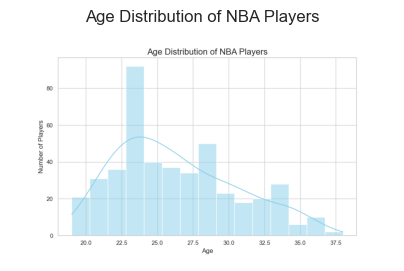

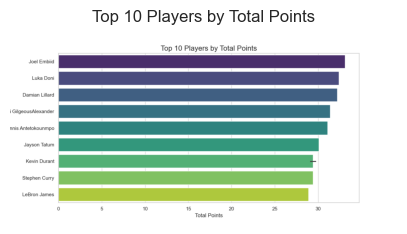

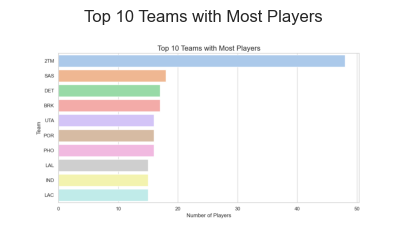

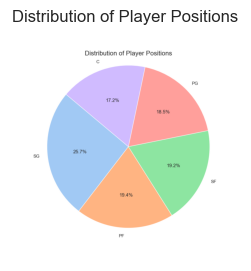

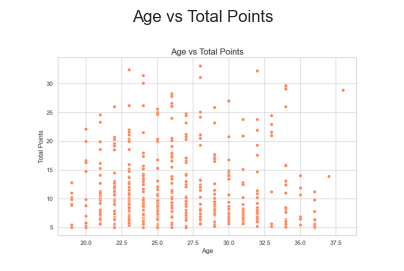

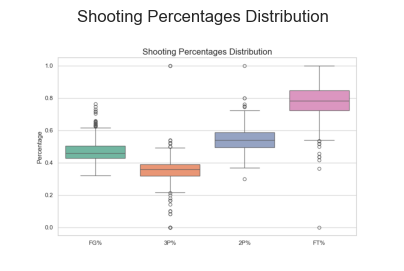

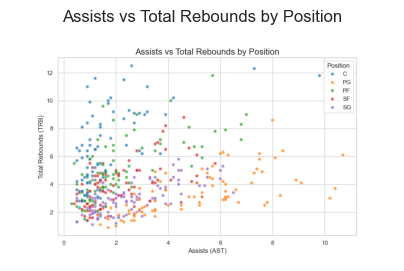

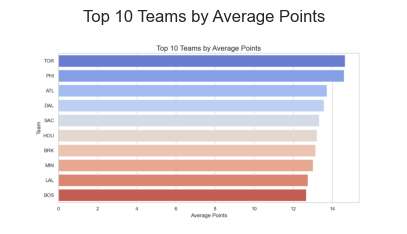

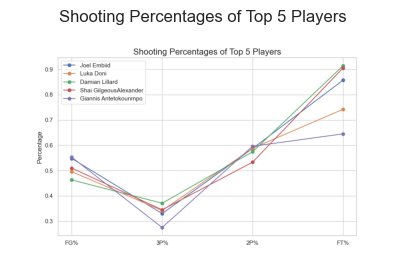

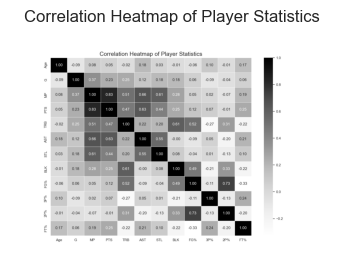

In [407]:
from pymongo import MongoClient
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

client = MongoClient('mongodb://localhost:27017/')
db = client['nba_database']
collection = db['myvisual']

documents = list(collection.find({}))

for doc in documents:
    title = doc['title']
    image_data = base64.b64decode(doc['image'])
    image = Image.open(BytesIO(image_data))
    

    plt.figure(figsize=(5,3))
    plt.imshow(image)
    plt.axis('off')
    plt.title(title)
    plt.show()

In [409]:
client = MongoClient('mongodb://localhost:27017/')
db = client['nba_database']
players_collection = db['players_stats']

In [411]:
players_collection.delete_many({})

DeleteResult({'n': 1792, 'ok': 1.0}, acknowledged=True)

In [413]:
csv_file_path = 'cleaned_players.csv'  
df = pd.read_csv(csv_file_path)

In [415]:
data = df.to_dict(orient='records')
players_collection.insert_many(data)

InsertManyResult([ObjectId('6810beafeed59a08da3057df'), ObjectId('6810beafeed59a08da3057e0'), ObjectId('6810beafeed59a08da3057e1'), ObjectId('6810beafeed59a08da3057e2'), ObjectId('6810beafeed59a08da3057e3'), ObjectId('6810beafeed59a08da3057e4'), ObjectId('6810beafeed59a08da3057e5'), ObjectId('6810beafeed59a08da3057e6'), ObjectId('6810beafeed59a08da3057e7'), ObjectId('6810beafeed59a08da3057e8'), ObjectId('6810beafeed59a08da3057e9'), ObjectId('6810beafeed59a08da3057ea'), ObjectId('6810beafeed59a08da3057eb'), ObjectId('6810beafeed59a08da3057ec'), ObjectId('6810beafeed59a08da3057ed'), ObjectId('6810beafeed59a08da3057ee'), ObjectId('6810beafeed59a08da3057ef'), ObjectId('6810beafeed59a08da3057f0'), ObjectId('6810beafeed59a08da3057f1'), ObjectId('6810beafeed59a08da3057f2'), ObjectId('6810beafeed59a08da3057f3'), ObjectId('6810beafeed59a08da3057f4'), ObjectId('6810beafeed59a08da3057f5'), ObjectId('6810beafeed59a08da3057f6'), ObjectId('6810beafeed59a08da3057f7'), ObjectId('6810beafeed59a08da3057

In [417]:
import streamlit as st
import pandas as pd
from pymongo import MongoClient
import base64
from PIL import Image
from io import BytesIO

st.set_page_config(
    page_title="NBA Players Analysis", 
    page_icon="🏀", 
    layout="wide",
    initial_sidebar_state="expanded"
)


st.sidebar.title("NBA Dashboard")
st.sidebar.markdown("""
Welcome to NBA analysis
""")
st.sidebar.markdown("---")
st.sidebar.write("📁made by logic lords team")

st.title("full NBA analysis 🏀")
st.markdown("explore players ,figures and visualisation.")

page_bg = """
<style>
body {
    background-color: #F5F5F5;
}
</style>
"""
st.markdown(page_bg, unsafe_allow_html=True)

2025-04-29 15:10:30.241 
  command:

    streamlit run D:\NF\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

In [422]:
client = MongoClient("mongodb://localhost:27017/")
db = client["nba_database"] 
players_collection = db['players_stats']

data=list(players_collection.find())
df=pd.DataFrame(data)

if '_id' in df.columns:
    df.drop('_id',axis=1,inplace=True)
    
df.drop_duplicates(inplace=True)

total_players = df['Player'].nunique()
total_teams = df['Team'].nunique()
top_scorer = df.sort_values(by='PTS', ascending=False).iloc[0]['Player']

st.markdown("## 📊 overview")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(label="number of players", value=total_players)

with col2:
    st.metric(label="number of teams", value=total_teams)

with col3:
    st.metric(label="best player", value=top_scorer)

In [429]:
st.markdown("## 📈 visualisation")


collection = db["myvisual"]  
plots = list(collection.find())


for plot in plots:
    title = plot['title']
    image_data = plot['image']

    
    image = Image.open(BytesIO(base64.b64decode(image_data)))

    st.subheader(f"📌 {title}")
    st.image(image)
    
    st.markdown("---")

In [427]:
st.sidebar.download_button(
    label="📥 download csv_file",
    data=df.to_csv(index=False).encode('utf-8'),
    file_name='cleand_players.csv',
    mime='text/csv'
)
st.header("player exploration")
data = list(players_collection.find())
df = pd.DataFrame(data)

st.title("player details:")

teams = df['Team'].unique()
selected_team = st.selectbox("choose your team:", teams)

filtered_df = df[df['Team'] == selected_team]
players = filtered_df['Player'].unique()
selected_player = st.selectbox("choose player", players)

player_info = filtered_df[filtered_df['Player'] == selected_player]

st.subheader(f"details: {selected_player}")
st.dataframe(player_info)

2025-04-29 15:14:29.398 Session state does not function when running a script without `streamlit run`
2025-04-29 15:14:29.529 Serialization of dataframe to Arrow table was unsuccessful due to: ("Could not convert ObjectId('6810beafeed59a08da3057df') with type ObjectId: did not recognize Python value type when inferring an Arrow data type", 'Conversion failed for column _id with type object'). Applying automatic fixes for column types to make the dataframe Arrow-compatible.


DeltaGenerator()